## Models
LLMs are powerful AI tools that can interpret and generate text like humans. They’re versatile enough to write content, translate languages, summarize, and answer questions without needing specialized training for each task.

In addition to text generation, many models support:

- Tool calling - calling external tools (like databases queries or API calls) and use results in their responses.
- Structured output - where the model’s response is constrained to follow a defined format.
- Multimodality - process and return data other than text, such as images, audio, and video.
- Reasoning - models perform multi-step reasoning to arrive at a conclusion.


### Basic usage
Models can be utilized in two ways:

1. With agents - Models can be dynamically specified when creating an agent.
2. Standalone - Models can be called directly (outside of the agent loop) for tasks like text generation, classification, or extraction without the need for an agent framework.

The same model interface works in both contexts, which gives you the flexibility to start simple and scale up to more complex agent-based workflows as needed.

### Initialize a model

In [21]:
import os
from langchain_openrouter import ChatOpenRouter

os.environ["OPENROUTER_API_KEY"] = "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"

model = ChatOpenRouter(model="openai/gpt-4o-mini", # "auto" can be an option
                       max_tokens=200,
                       temperature=0.7,)

response = model.invoke("Hi, Which model are you using?")
print(response)

content="I am based on OpenAI's GPT-3.5 architecture. How can I assist you today?" additional_kwargs={} response_metadata={'model_name': 'openai/gpt-4o-mini', 'id': 'gen-1778562468-3OXQOn8idKCH9DdkKqaE', 'created': 1778562468, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter', 'system_fingerprint': 'fp_eb37e061ec'} id='lc_run--019e1a95-8b5f-7812-8de5-8e4d650b4848-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 15, 'output_tokens': 22, 'total_tokens': 37, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning': 0}}


### Parameters


model       string  required

api_key     string

temperature number

max_tokens  number

timeout     number

max_retries number  default:"6"



### Invocation
A chat model must be invoked to generate an output. There are three primary invocation methods, each suited to different use cases.

#### 1. Invoke
The most straightforward way to call a model is to use invoke() with a single message or a list of messages.

In [13]:
from IPython.display import Markdown, display
response = model.invoke("Why the sky is blue?")
display(Markdown(response.content))

The sky appears blue primarily due to a phenomenon called Rayleigh scattering. Here’s how it works:

1. **Sunlight Composition**: Sunlight, or white light, is composed of various colors, each with different wavelengths. Blue light has a shorter wavelength, while red light has a longer wavelength.

2. **Atmospheric Interaction**: When sunlight enters the Earth's atmosphere, it interacts with air molecules and small particles. Because blue light has a shorter wavelength, it is scattered in all directions more effectively than the other colors.

3. **Perception**: As we look up at the sky, we see this scattered blue light coming from all directions. This is why the sky appears predominantly blue during the day.

4. **Variations**: The color of the sky can change under different conditions. For example, during sunrise or sunset, the sunlight passes through more atmosphere, scattering the shorter blue wavelengths and allowing the longer red and orange wavelengths to dominate, resulting in the warm colors we see.

In summary, the blue appearance of the sky is due to the scattering of sunlight by the atmosphere, with blue light being scattered more than other colors due to its shorter wavelength.

A list of messages can be provided to a chat model to represent conversation history. 

Each message has a role that models use to indicate who sent the message in the conversation.

This can be done in two different ways

In [15]:
conversation = [
    {"role": "system", "content": "You are a helpful assistant. please translate the following sentence to French."},
    {"role": "user", "content": "I love cooking?"},
    {"role": "assistant", "content": "J'aime cuisiner."},
    {"role": "user", "content": "Translate : I love food from different cuisines"}
]

response = model.invoke(conversation)
display(Markdown(response.content))
print(response)

J'adore la nourriture de différentes cuisines.

content="J'adore la nourriture de différentes cuisines." additional_kwargs={} response_metadata={'model_name': 'openai/gpt-4o-mini', 'id': 'gen-1778562165-f6q2uGF3Z2lmBJquBCcF', 'created': 1778562165, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter', 'system_fingerprint': 'fp_eb37e061ec'} id='lc_run--019e1a90-e8e2-71c2-bba9-86b224a09c95-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 50, 'output_tokens': 9, 'total_tokens': 59, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning': 0}}


In [17]:
from langchain.messages import HumanMessage, AIMessage, SystemMessage
conversation = [
    SystemMessage("You are a helpful assistant. please translate the following sentence to French."),
    HumanMessage("I love cooking?"),
    AIMessage("J'aime cuisiner."),
    HumanMessage("Translate : I love food from different cuisines")
]

response = model.invoke(conversation)
display(Markdown(response.content))
print(response)

J'aime la nourriture de différentes cuisines.

content="J'aime la nourriture de différentes cuisines." additional_kwargs={} response_metadata={'model_name': 'openai/gpt-4o-mini', 'id': 'gen-1778562263-DrWBezMLUEjlgop3qrGH', 'created': 1778562263, 'object': 'chat.completion', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'openrouter', 'system_fingerprint': 'fp_eb37e061ec'} id='lc_run--019e1a92-6ace-7623-ab03-eddeef26bfde-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 50, 'output_tokens': 9, 'total_tokens': 59, 'input_token_details': {'cache_read': 0, 'cache_creation': 0}, 'output_token_details': {'reasoning': 0}}


#### 2. Stream
Most models can stream their output content while it is being generated. By displaying output progressively, streaming significantly improves user experience, particularly for longer responses.

Calling stream() returns an iterator that yields output chunks as they are produced. You can use a loop to process each chunk in real-time:

In [23]:
for chunk in model.stream("Why the sky is blue?"):
    print(chunk.content, end="|", flush=True)

The| sky| appears| blue| due| to| a| phenomenon| called| Ray|leigh| scattering|.| When| sunlight| enters| Earth's| atmosphere|,| it| is| made| up| of| different| colors| of| light|,| each| with| varying| wavelengths|.| Blue| light| has| a| shorter| wavelength| compared| to| other| colors| like| red| or| yellow|.

|As| sunlight| passes| through| the| atmosphere|,| it| coll|ides| with| gas| molecules| and| small| particles|.| Because| blue| light| is| scattered| more| effectively| than| other| colors| due| to| its| shorter| wavelength|,| it| spreads| in| all| directions| and| gives| the| sky| its| characteristic| blue| color|.

|During| sunrise| and| sunset|,| the| sun| is| lower| in| the| sky|,| and| its| light| passes| through| a| thicker| layer| of| the| atmosphere|.| This| causes| more| scattering| of| the| shorter| wavelengths| and| allows| the| longer| wavelengths|,| like| red| and| orange|,| to| dominate|,| leading| to| the| beautiful| colors| often| seen| at| those| times|.||||

#### Batch
Batching a collection of independent requests to a model can significantly improve performance and reduce costs, as the processing can be done in parallel:

In [24]:
responses = model.batch([
    "Why do parrots have colorful feathers?",
    "How do airplanes fly?",
    "What is quantum computing?"
])
for response in responses:
    print(response)

content='Parrots have colorful feathers for several reasons, primarily related to their survival, social behavior, and mating strategies. Here are some key factors:\n\n1. **Camouflage**: In their natural habitats, which are often lush and vibrant rainforests, bright colors can help parrots blend in with the foliage, making it harder for predators to spot them.\n\n2. **Social Interaction**: Colorful feathers can play a significant role in communication among parrots. Bright colors may help signal health and vitality to other parrots, as vibrant plumage can indicate a well-nourished individual.\n\n3. **Mating Displays**: Many male parrots have brighter and more vivid colors than females, which can attract potential mates. The intensity of their coloration may signal genetic fitness, making them more appealing during courtship.\n\n4. **Species Identification**: The distinctive colors and patterns of feathers help parrots identify members of their own species, which is crucial for social c

By default, batch() will only return the final output for the entire batch. If you want to receive the output for each individual input as it finishes generating, you can stream results with batch_as_completed():

In [25]:
for response in model.batch_as_completed([
    "Why do parrots have colorful feathers?",
    "How do airplanes fly?",
    "What is quantum computing?"
]):
    print(response)

(2, AIMessage(content='Quantum computing is a field of computing that leverages the principles of quantum mechanics to process information in fundamentally different ways than classical computers. Unlike classical bits, which can represent either a 0 or a 1, quantum bits, or qubits, can exist in a superposition of states. This means a qubit can be in a state representing 0, 1, or both at the same time.\n\nKey concepts in quantum computing include:\n\n1. **Superposition**: Qubits can be in multiple states simultaneously, enabling quantum computers to process a vast amount of information at once.\n\n2. **Entanglement**: Qubits can become entangled, meaning the state of one qubit is directly related to the state of another, no matter how far apart they are. This property can be used to perform complex calculations more efficiently.\n\n3. **Quantum Interference**: Quantum states can interfere with one another, allowing quantum algorithms to amplify correct solutions while canceling out inc

## Tool Calling

Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code. Tools are pairings of:
1. A schema, including the name of the tool, a description, and/or argument definitions (often a JSON schema)
2. A function or coroutine to execute.



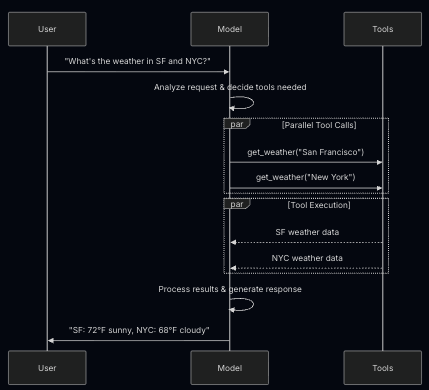


To make tools that you have defined available for use by a model, you must bind them using bind_tools. In subsequent invocations, the model can choose to call any of the bound tools as needed.

In [26]:
from langchain.tools import tool

@tool
def get_weather(location: str) -> str:
    """Get the weather at a location."""
    return f"It's sunny in {location}."


model_with_tools = model.bind_tools([get_weather])

response = model_with_tools.invoke("What's the weather like in Boston?")
for tool_call in response.tool_calls:
    # View tool calls made by the model
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

Tool: get_weather
Args: {'location': 'Boston'}


### Tool execution Loop
When a model returns tool calls, you need to execute the tools and pass the results back to the model. This creates a conversation loop where the model can use tool results to generate its final response. LangChain includes agent abstractions that handle this orchestration for you.

In [39]:

# Bind (potentially multiple) tools to the model
model_with_tools = model.bind_tools([get_weather])

# Step 1: Model generates tool calls
messages = [
    {"role": "system", "content": "You are a helpful assistant that can provide weather information."},
    {"role": "user", "content": "What's the weather in Kolkata?"}
]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)
tools = {'get_weather': get_weather}

# Step 2: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    # Execute the tool with the generated arguments
    tool_result = tools[tool_call["name"]].invoke(tool_call)
    messages.append(tool_result)

# Step 3: Pass results back to model for final response
response = model_with_tools.invoke(messages)
print(response.content) 



The weather in Kolkata is sunny.


### Forcing tool calls
By default, the model has the freedom to choose which bound tool to use based on the user’s input. However, you might want to force choosing a tool, ensuring the model uses either a particular tool or any tool from a given list:

In [ ]:
# Force use of any tool
model_with_tools = model.bind_tools([get_weather], tool_choice="any")

# Force use of a specific tool
model_with_tools = model.bind_tools([get_weather], tool_choice="get_weather")

### Parallel tool calls

Many models support calling multiple tools in parallel when appropriate. This allows the model to gather information from different sources simultaneously.

In [ ]:
model_with_tools = model.bind_tools([get_weather])

response = model_with_tools.invoke(
    "What's the weather in Boston and Tokyo?"
)


# The model may generate multiple tool calls
print(response.tool_calls)
# [
#   {'name': 'get_weather', 'args': {'location': 'Boston'}, 'id': 'call_1'},
#   {'name': 'get_weather', 'args': {'location': 'Tokyo'}, 'id': 'call_2'},
# ]


# Execute all tools (can be done in parallel with async)
results = []
for tool_call in response.tool_calls:
    if tool_call['name'] == 'get_weather':
        result = get_weather.invoke(tool_call)
    ...
    results.append(result)

### Streaming tool calls
When streaming responses, tool calls are progressively built through ToolCallChunk. This allows you to see tool calls as they’re being generated rather than waiting for the complete response.

In [40]:
for chunk in model_with_tools.stream(
    "What's the weather in Boston and Tokyo?"
):
    # Tool call chunks arrive progressively
    for tool_chunk in chunk.tool_call_chunks:
        if name := tool_chunk.get("name"):
            print(f"Tool: {name}")
        if id_ := tool_chunk.get("id"):
            print(f"ID: {id_}")
        if args := tool_chunk.get("args"):
            print(f"Args: {args}")

# Output:
# Tool: get_weather
# ID: call_SvMlU1TVIZugrFLckFE2ceRE
# Args: {"lo
# Args: catio
# Args: n": "B
# Args: osto
# Args: n"}
# Tool: get_weather
# ID: call_QMZdy6qInx13oWKE7KhuhOLR
# Args: {"lo
# Args: catio
# Args: n": "T
# Args: okyo
# Args: "}

Tool: get_weather
ID: call_zcZvzXvQq6fFEHeQ7yzsQ6OM
Args: {"lo
Args: catio
Args: n": "B
Args: osto
Args: n"}
Tool: get_weather
ID: call_c7z8eJgjwqZN3u5yssgHtEo5
Args: {"lo
Args: catio
Args: n": "T
Args: okyo
Args: "}


## Structured Output
Models can be requested to provide their response in a format matching a given schema. This is useful for ensuring the output can be easily parsed and used in subsequent processing. LangChain supports multiple schema types and methods for enforcing structured output.

In [45]:
from typing_extensions import TypedDict, Annotated

class MovieDict(TypedDict):
    """A movie with details."""
    title: Annotated[str, ..., "The title of the movie"]
    year: Annotated[int, ..., "The year the movie was released"]
    director: Annotated[str, ..., "The director of the movie"]
    rating: Annotated[float, ..., "The movie's rating out of 10"]

model_with_structure = model.with_structured_output(MovieDict)
response = model_with_structure.invoke("Provide details about the movie pather panchali")
print(response)  # {'title': 'Pather Panchali', 'year': 1955, 'director': 'Satyajit Ray', 'rating': 8.5}

{'title': 'Pather Panchali', 'year': 1955, 'director': 'Satyajit Ray', 'rating': 8.5}


## Reasoning

Many models are capable of performing multi-step reasoning to arrive at a conclusion. This involves breaking down complex problems into smaller, more manageable steps.
If supported by the underlying model, you can surface this reasoning process to better understand how the model arrived at its final answer.

In [ ]:
# Stream reasoning output
for chunk in model.stream("Why do parrots have colorful feathers?"):
    reasoning_steps = [r for r in chunk.content_blocks if r["type"] == "reasoning"]
    print(reasoning_steps if reasoning_steps else chunk.text)



Par
rots
 have
 colorful
 feathers
 for
 several
 reasons
,
 primarily
 related
 to
 communication
,
 camouflage
,
 and
 mate
 attraction
.
 Here
 are
 some
 key
 factors
:


1
.
 **
Communication
**
:
 Bright
 colors
 can
 help
 parro
ts
 communicate
 with
 each
 other
.
 In
 dense
 forests
 where
 they
 often
 live
,
 vibrant
 colors
 may
 help
 them
 identify
 one
 another
 from
 a
 distance
.


2
.
 **
Cam
ouflage
**
:
 While
 bright
 colors
 may
 seem
 counter
int
uitive
 for
 camouflage
,
 many
 parro
ts
'
 colors
 mimic
 the
 vibrant
 hues
 of
 their
 natural
 habitats
,
 such
 as
 flowers
 and
 foliage
.
 This
 can
 help
 them
 blend
 into
 their
 surroundings
 and
 avoid
 predators
.


3
.
 **
Mate
 Attraction
**
:
 In
 many
 species
,
 brighter
 and
 more
 vibrant
 feathers
 are
 often
 a
 sign
 of
 health
 and
 vitality
.
 M
ales
 might
 display
 their
 colorful
 plum
age
 to
 attract
 females
,
 who
 may
 prefer
 mates
 with
 the
 most
 vivid
 colors
.


4
.
 **
Species
 Id

In [ ]:
# Complete reasoning output after the model finishes
response = model.invoke("Why do parrots have colorful feathers?")
reasoning_steps = [b for b in response.content_blocks if b["type"] == "reasoning"]
print(" ".join(step["reasoning"] for step in reasoning_steps))

In [54]:
response = model.invoke(
    "Tell me a joke",
    config={
        "run_name": "joke_generation",      # Custom name for this run
        "tags": ["humor", "demo"],          # Tags for categorization
        "subject" : ["global politics", "donald trump", "trade war"],
        "metadata": {"user_id": "123"},     # Custom metadata
        #"callbacks": [my_callback_handler], # Callback handlers
    }
)
print(response.content)

Why did the scarecrow win an award? 

Because he was outstanding in his field!
